In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/credit-scoring-project/data/application_train.csv')

print(df.shape)
print(df.dtypes)

(307511, 122)
SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object


In [3]:
print(df['TARGET'].value_counts())
print(df['TARGET'].value_counts(normalize=True))

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(30))

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_AVG             204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_AVG                182590
LANDAREA_MODE               182590
BASEMENTAREA_MODE           179943
BASEMENTAREA_MEDI           179943
BASEMENTAREA_AVG            179943
EXT_SOURCE_1                173378
NONLIVINGAREA_MODE          169682
NONLIVINGAREA_AVG           169682
NONLIVINGAREA_MEDI          169682
ELEVATORS_AVG               163891
ELEVATORS_MEDI      

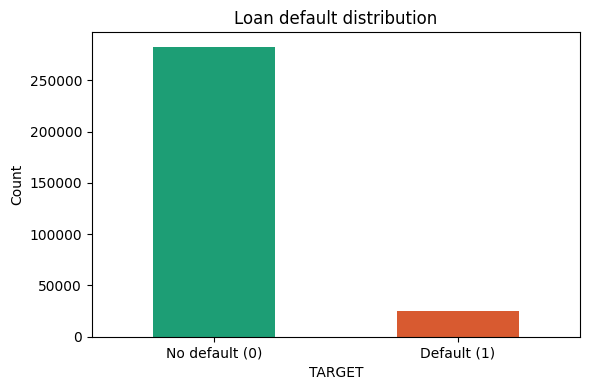

In [5]:
plt.figure(figsize=(6,4))
df['TARGET'].value_counts().plot(kind='bar', color=['#1D9E75','#D85A30'])
plt.title('Loan default distribution')
plt.xticks([0,1], ['No default (0)','Default (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/credit-scoring-project/reports/class_balance.png')
plt.show()

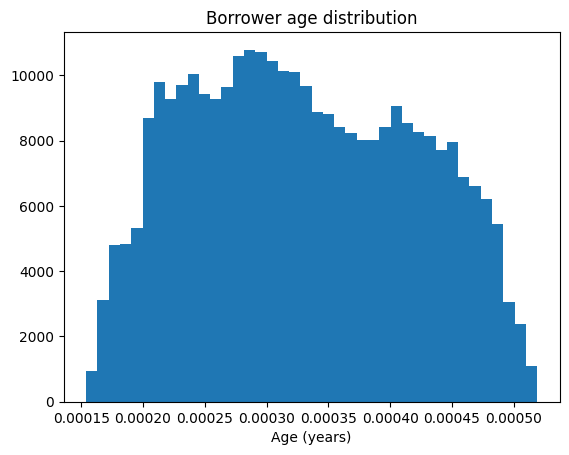

In [13]:
df['DAYS_BIRTH'] = df['DAYS_BIRTH'].abs() / 365

plt.hist(df['DAYS_BIRTH'], bins=40)
plt.xlabel('Age (years)')
plt.title('Borrower age distribution')
plt.savefig('/content/drive/MyDrive/credit-scoring-project/reports/age_distribution.png')
plt.show()

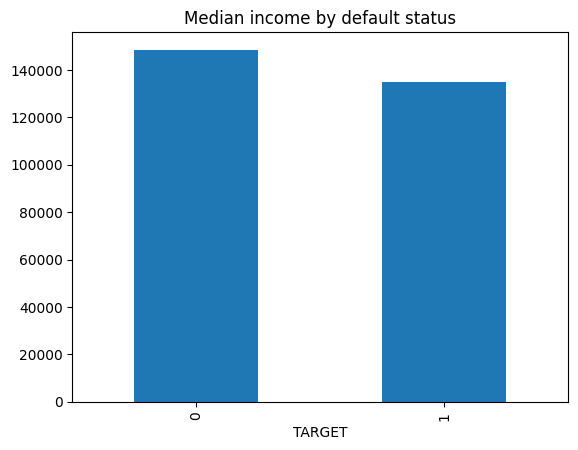

In [14]:
df.groupby('TARGET')['AMT_INCOME_TOTAL'].median().plot(kind='bar')
plt.title('Median income by default status')
plt.savefig('/content/drive/MyDrive/credit-scoring-project/reports/income_vs_default.png')
plt.show()

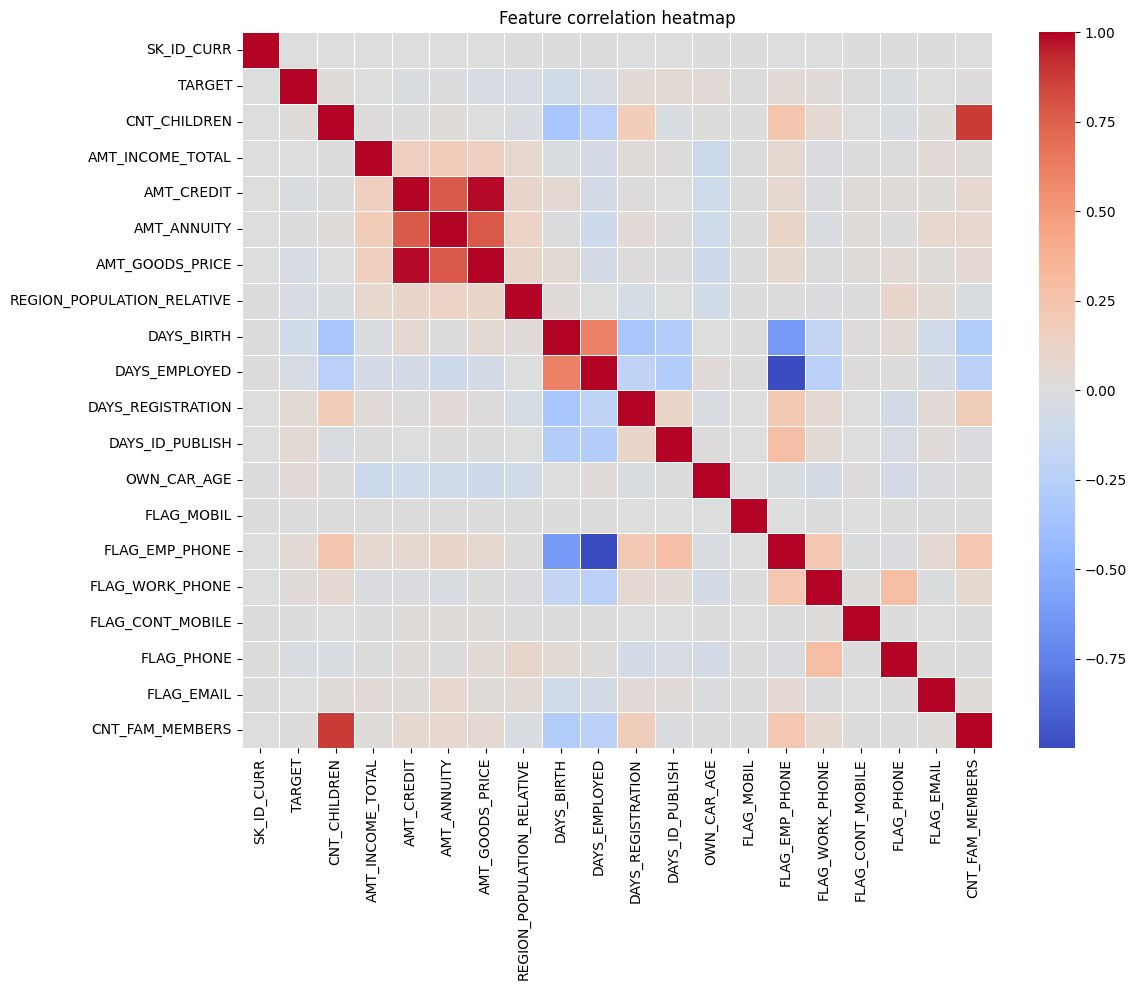

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns[:20]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/credit-scoring-project/reports/correlation_heatmap.png')
plt.show()

In [16]:
import os

os.listdir('/content/drive/MyDrive/credit-scoring-project/reports')

['class_balance.png',
 'age_distribution.png',
 'income_vs_default.png',
 'correlation_heatmap.png']